In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

In [2]:
#============================= 딥러닝을 위한 데이터로더 만들기 ========================
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    #데잍터를 텐서로 변환
    # torch.tensor() : 날 것의 데이터(np.array)를 파이토치 전용 규격(연료)으로 바꾼다.
    
    x_train_tensor = torch.tensor(np.array(x_train), dtype=torch.float32)       
    y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(np.array(x_val), dtype=torch.float32)
    y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.float32).view(-1, 1)

    # TensorDataset : 문제지(X)와 정답지(y)를 한 세트로 묶어 낱개 상품으로 포장
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader: 낱개 상품들을 batch_size만큼 박스때기로 묶고, 골고루 섞어서 트럭에 실어 모델에게 실시간으로 배달
    train_loader= DataLoader(train_dataset, batch_size = batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor


In [3]:
# ============================= train 학습을 위한 함수===============================
def train(dataloader, model, loss_fn, optimizer, device):
    
    model.train()
    total_loss = 0

    for x, y in dataloader:
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()           # 이전 배치의 gradient 초기화
        pred = model(x)                 # 모델에 지정된 장치에 이동된 입력 데이터를 넣는다.
        loss = loss_fn(pred,y)          # 손실함수에 모델에 들어간 예측값과 실제 레이블 값을 비교하여 저장

        loss.backward()                 # 역전파를 통하여 weight를 구한다.
        optimizer.step()                # weight를 이용하여 모델 파라미터 업데이트

        total_loss +=loss.item() * x.size(0) # loss.item()은 배치의 평균 손실 그 후 평균 손실에 배치만크 곱해야 총 loss

    return total_loss / len(dataloader.dataset)

In [4]:
#=============================== evaluate 검증을 위한 함수=============================

def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):

    model.eval()         #모델을 평가 모드로

    with torch.no_grad():              # 지금부터 이 들여쓰기 안쪽 코드가 끝날 때까지, 미분(기울기) 계산 기록 장치를 잠시 꺼두겠다
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred,y).item()

    return eval_loss, pred 

In [17]:
#=============================== 학습 곡선 함수(같은 파일 위치 내 results파일에 저장) =========================================

def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


In [9]:
path = '../../dataset/preprocessed/hotel_bookings_dummy.csv'
df = pd.read_csv(path)

In [10]:
df.head()

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,...,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,guest_type_Group,guest_type_Single,guest_type_Undefined,country_region_OTH,country_region_PRT
0,0,342,0,0,0,0,0,3,0,0.0,...,0,0,0,1,0,1,0,0,0,1
1,0,737,0,0,0,0,0,4,0,0.0,...,0,0,0,1,0,1,0,0,0,1
2,0,7,0,1,0,0,0,0,0,75.0,...,0,0,0,1,0,0,1,0,0,0
3,0,13,0,1,0,0,0,0,0,75.0,...,0,0,0,1,0,0,1,0,0,0
4,0,14,0,2,0,0,0,0,0,98.0,...,0,0,0,1,0,1,0,0,0,0


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118902 entries, 0 to 118901
Data columns (total 52 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   is_canceled                     118902 non-null  int64  
 1   lead_time                       118902 non-null  int64  
 2   stays_in_weekend_nights         118902 non-null  int64  
 3   stays_in_week_nights            118902 non-null  int64  
 4   is_repeated_guest               118902 non-null  int64  
 5   previous_cancellations          118902 non-null  int64  
 6   previous_bookings_not_canceled  118902 non-null  int64  
 7   booking_changes                 118902 non-null  int64  
 8   days_in_waiting_list            118902 non-null  int64  
 9   adr                             118902 non-null  float64
 10  required_car_parking_spaces     118902 non-null  int64  
 11  total_of_special_requests       118902 non-null  int64  
 12  diff_reserved_room_type    

In [13]:
target = 'is_canceled'
X = df.drop(target, axis = 1)
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(X,y,
                                                  test_size = .3,
                                                  random_state = 1004)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

train_loader, X_val_ts, y_val_ts = make_DataSet(X_train,
                                                X_val,
                                                y_train,
                                                y_val,
                                                batch_size =32)

n_feature = X.shape[1]

In [14]:
# 모델 구조 설계
model = nn.Sequential(
    nn.Linear(n_feature,5),         #은닉층
    nn.ReLU(),                      #은닉층 활성화 함수
    nn.Linear(5,1),                 #출력층
    nn.Sigmoid()                    #출력층 활성화 함수
).to(device)

loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(),lr=0.001)

In [15]:
epochs = 100
tr_loss_list, val_loss_list = [],[]

for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.440127, val loss : 0.399936
Epoch 2, train loss : 0.382134, val loss : 0.377836
Epoch 3, train loss : 0.363723, val loss : 0.367040
Epoch 4, train loss : 0.357060, val loss : 0.363855
Epoch 5, train loss : 0.354063, val loss : 0.361338
Epoch 6, train loss : 0.351812, val loss : 0.359033
Epoch 7, train loss : 0.349908, val loss : 0.356650
Epoch 8, train loss : 0.347952, val loss : 0.354815
Epoch 9, train loss : 0.346216, val loss : 0.353213
Epoch 10, train loss : 0.344620, val loss : 0.353664
Epoch 11, train loss : 0.343317, val loss : 0.351300
Epoch 12, train loss : 0.342324, val loss : 0.352414
Epoch 13, train loss : 0.341479, val loss : 0.350053
Epoch 14, train loss : 0.341011, val loss : 0.352332
Epoch 15, train loss : 0.340583, val loss : 0.351406
Epoch 16, train loss : 0.341376, val loss : 0.351229
Epoch 17, train loss : 0.341849, val loss : 0.352447
Epoch 18, train loss : 0.342457, val loss : 0.360623
Epoch 19, train loss : 0.341066, val loss : 0.359638
Ep

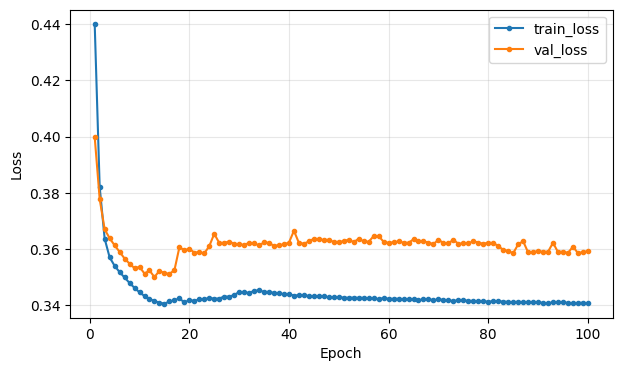

In [18]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [19]:
_,pred = evaluate(X_val_ts,y_val_ts, model, loss_fn,device)
y_true_np = y_val_ts.numpy()

pred_class = np.where(pred.cpu().numpy()>0.5,1,0)  #확률이 0.5보다 크면 1, 작으면 0으로 변환
print(confusion_matrix(y_val_ts.numpy(),pred_class))
print(classification_report(y_val_ts.cpu().numpy(),pred_class))


[[20630  1760]
 [ 4126  9155]]
              precision    recall  f1-score   support

         0.0       0.83      0.92      0.88     22390
         1.0       0.84      0.69      0.76     13281

    accuracy                           0.83     35671
   macro avg       0.84      0.81      0.82     35671
weighted avg       0.84      0.83      0.83     35671



In [20]:
mlp_accuracy = accuracy_score(y_true_np, pred_class)
mlp_macro_f1 = f1_score(y_true_np, pred_class, average='macro')

# 클래스별 f1-score 리스트에서 1번(취소) 클래스만 추출
mlp_each_f1 = f1_score(y_true_np, pred_class, average=None)
mlp_cancel_f1 = mlp_each_f1[1]

In [22]:
mlp_res = pd.DataFrame({
    'Model': ['MLP'],
    'Accuracy': [mlp_accuracy],        
    'F1_Macro': [mlp_macro_f1],        
    'F1_Cancel': [mlp_cancel_f1]       
})

# 그 후 'visualization/model_results' 폴더로 정확하게 연결
output_dir = '../../visualization/model_results'
os.makedirs(output_dir, exist_ok=True) 

# csv 파일로 최종 저장
mlp_res.to_csv(f'{output_dir}/mlp_result.csv', index=False)
print(f"\n✅ DNN 모델 검증 결과가 공용 폴더에 무사히 배달되었습니다! ➡️ {output_dir}/dnn_result.csv")


✅ DNN 모델 검증 결과가 공용 폴더에 무사히 배달되었습니다! ➡️ ../../visualization/model_results/dnn_result.csv
